### Predicting Customer Subscription to Term Deposits Using Marketing Campaign Data

#### Business Problem Statement:
A bank conducts direct marketing campaigns through phone calls to promote term deposit products. However, contacting every customer is costly and time-consuming, while only a small percentage of customers subscribe to the product.

### KPQ:

1) Which communication method (telephone, cellular, etc.) generates the highest conversion rate?
2) Which jobs have the highest subscription rates?
3) Do older customers subscribe more often?
4) Does call duration differ between subscribers and non-subscribers?
5) Does a successful previous campaign increase conversion rates?


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import recall_score,precision_score,accuracy_score,f1_score,classification_report,confusion_matrix,ConfusionMatrixDisplay


In [3]:
#Load the dataset
try:
    data = pd.read_csv("data/bank.csv")
    print("Data successfully Loaded")

except FileNotFoundError as e:
    print(f'File error is {e}')

Data successfully Loaded


In [4]:
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [6]:
data.describe(include='all')

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
count,11162.000000,11162,11162,11162,11162,11162.000000,11162,11162,11162,11162.000000,11162,11162.000000,11162.000000,11162.000000,11162.000000,11162,11162
unique,NaN,12,3,4,2,NaN,2,2,3,NaN,12,NaN,NaN,NaN,NaN,4,2
top,NaN,management,married,secondary,no,NaN,no,no,cellular,NaN,may,NaN,NaN,NaN,NaN,unknown,no
freq,NaN,2566,6351,5476,10994,NaN,5881,9702,8042,NaN,2824,NaN,NaN,NaN,NaN,8326,5873
mean,41.231948,NaN,NaN,NaN,NaN,1528.538524,NaN,NaN,NaN,15.658036,NaN,371.993818,2.508421,51.330407,0.832557,NaN,NaN
std,11.913369,NaN,NaN,NaN,NaN,3225.413326,NaN,NaN,NaN,8.420740,NaN,347.128386,2.722077,108.758282,2.292007,NaN,NaN
min,18.000000,NaN,NaN,NaN,NaN,-6847.000000,NaN,NaN,NaN,1.000000,NaN,2.000000,1.000000,-1.000000,0.000000,NaN,NaN
25%,32.000000,NaN,NaN,NaN,NaN,122.000000,NaN,NaN,NaN,8.000000,NaN,138.000000,1.000000,-1.000000,0.000000,NaN,NaN
50%,39.000000,NaN,NaN,NaN,NaN,550.000000,NaN,NaN,NaN,15.000000,NaN,255.000000,2.000000,-1.000000,0.000000,NaN,NaN
75%,49.000000,NaN,NaN,NaN,NaN,1708.000000,NaN,NaN,NaN,22.000000,NaN,496.000000,3.000000,20.750000,1.000000,NaN,NaN


In [7]:
data.isnull().sum()


age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [8]:
data.duplicated().sum()

0

In [9]:
demograph = data.groupby(['deposit','education'])[['marital']].agg(total_count = ('marital','count'))
demograph['percentage'] = ((demograph['total_count'])/demograph.groupby('deposit')['total_count'].sum())*100
demograph

total_count  percentage
deposit education                         
no      primary            909   15.477609
        secondary         3026   51.523923
        tertiary          1693   28.826835
        unknown            245    4.171633
yes     primary            591   11.174135
        secondary         2450   46.322556
        tertiary          1996   37.738703
        unknown            252    4.764606

Customers with secondary and tertiary education represent the largest share of successful term deposit subscriptions. This suggests educational background may influence financial product adoption.

#### 1) Which communication method (telephone, cellular, etc.) generates the highest conversion rate?

In [10]:
communicatio_method = data.groupby(['deposit','contact']).agg(total_count = ('age','count'))
communicatio_method['percentage'] = ((communicatio_method['total_count'])/communicatio_method.groupby('deposit')['total_count'].sum())*100
communicatio_method

total_count  percentage
deposit contact                           
no      cellular          3673   62.540439
        telephone          384    6.538396
        unknown           1816   30.921165
yes     cellular          4369   82.605407
        telephone          390    7.373795
        unknown            530   10.020798

Cellular communication generated a significantly higher proportion of successful subscriptions compared to telephone contact, indicating mobile-based outreach may be more effective.

Cellular communication achieved the highest conversion rate among all communication channels. Customers contacted through mobile phones were more likely to subscribe to term deposits compared to traditional telephone communication.

#### 2) Which jobs have the highest subscription rates?

In [11]:
data['job'].value_counts(normalize=True)*100

job
management       22.988712
blue-collar      17.416234
technician       16.332199
admin.           11.951263
services          8.269127
retired           6.970077
self-employed     3.628382
student           3.225228
unemployed        3.198352
entrepreneur      2.938541
housemaid         2.454757
unknown           0.627128
Name: proportion, dtype: float64

In [12]:
job_cat = data.groupby(['deposit','job']).agg(total_count = ('age','count'))
job_cat['percentage'] = ((job_cat['total_count'])/job_cat.groupby('deposit')['total_count'].sum())*100
job_cat

total_count  percentage
deposit job                                   
no      admin.                 703   11.970032
        blue-collar           1236   21.045462
        entrepreneur           205    3.490550
        housemaid              165    2.809467
        management            1265   21.539247
        retired                262    4.461093
        self-employed          218    3.711902
        services               554    9.432998
        student                 91    1.549464
        technician             983   16.737613
        unemployed             155    2.639196
        unknown                 36    0.612975
yes     admin.                 631   11.930422
        blue-collar            708   13.386273
        entrepreneur           123    2.325581
        housemaid              109    2.060881
        management            1301   24.598223
        retired                516    9.756098
        self-employed          187    3.535640
        services               369    6.976744
        student                269    5.086028
        technician             840   15.882019
        unemployed             202    3.819247
        unknown                 34    0.642844

Management, technician, and blue-collar	 customers show stronger participation in term deposit subscriptions, suggesting occupation influences campaign response behavior.

#### 3) Do older customers subscribe more often?

<Axes: xlabel='age'>

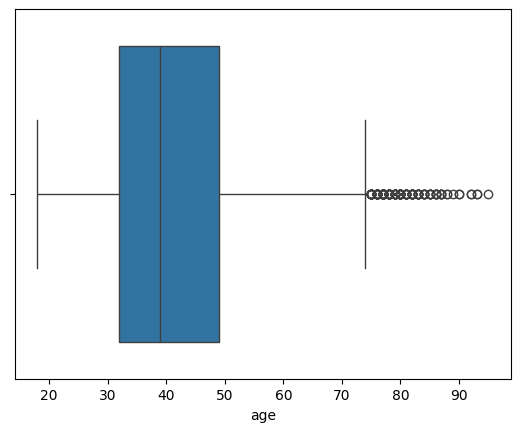

In [13]:
sns.boxplot(x=data['age'])

In [14]:
data['age_cat'] = pd.cut(data['age'],
                         bins=[0,25,35,45,55,65,100],
                         labels=['18-25','26-35','36-45','46-55','56-65','66+'])

In [15]:
age_group = data.groupby(['deposit','age_cat']).agg(total_count = ('age','count'))
age_group['percentage'] = (((age_group['total_count'])/age_group.groupby('deposit')['total_count'].sum())*100).round(2)
age_group=age_group.reset_index()

C:\Users\maneo\AppData\Local\Temp\ipykernel_21880\3405494413.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group = data.groupby(['deposit','age_cat']).agg(total_count = ('age','count'))


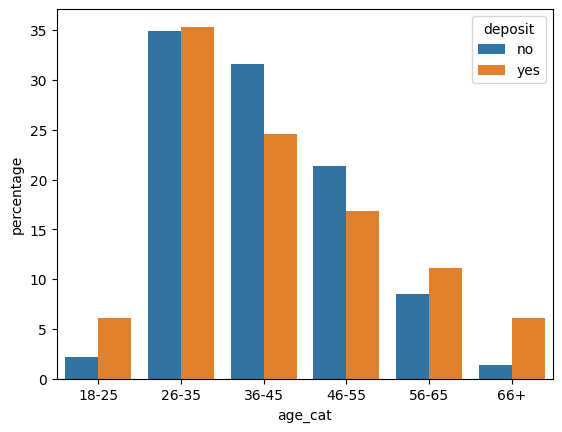

In [16]:
sns.barplot(x=age_group['age_cat'],y=age_group['percentage'],hue=age_group['deposit'])
plt.show()

Customers aged 26–45 represent the largest segment of subscribers, while older age groups show comparatively lower participation rates.Customers between 26 and 45 years old account for the highest proportion of successful subscriptions. Younger and middle-aged customers appear more responsive to marketing campaigns than older customer groups.

#### 4) Does call duration differ between subscribers and non-subscribers?

In [17]:
duration_df = data.groupby(['deposit'])[['duration']].mean()
duration_df

,duration
deposit,
no,223.130257
yes,537.294574


Successful subscriptions are associated with longer average call durations, suggesting deeper customer engagement increases conversion likelihood.

#### 5) Does a successful previous campaign increase conversion rates?

In [18]:
campaign_success = data[data['deposit']=='yes']

In [19]:
no_contact_success = campaign_success[campaign_success['previous']==0]
contact_success = campaign_success[campaign_success['previous']>0]

print('Total number of People Who have no contact in previous campaign have deposit plan: ',len(no_contact_success))
print('Total number of People who have contact in previous campaign have deposit plan: ',len(contact_success))
print('% of People who have contact in previous campaign have deposit plan: ',round((len(contact_success)/len(campaign_success))*100,2),"%")


Total number of People Who have no contact in previous campaign have deposit plan:  3384
Total number of People who have contact in previous campaign have deposit plan:  1905
% of People who have contact in previous campaign have deposit plan:  36.02 %


Customers contacted successfully in previous campaigns demonstrate a higher likelihood of subscribing, indicating prior engagement positively influences conversion outcomes.
Customers with prior successful interactions demonstrate a higher probability of subscribing to a term deposit. Historical engagement appears to be an important predictor of campaign success.


In [20]:
data = data.drop(columns=['age_cat'])

df = pd.get_dummies(data,drop_first='True',dtype='uint8')
df

,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown,deposit_yes
0,59,2343,5,1042,1,-1,0,0,0,0,...,0,0,1,0,0,0,0,0,1,1
1,56,45,5,1467,1,-1,0,0,0,0,...,0,0,1,0,0,0,0,0,1,1
2,41,1270,5,1389,1,-1,0,0,0,0,...,0,0,1,0,0,0,0,0,1,1
3,55,2476,5,579,1,-1,0,0,0,0,...,0,0,1,0,0,0,0,0,1,1
4,54,184,5,673,2,-1,0,0,0,0,...,0,0,1,0,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,1,20,257,1,-1,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
11158,39,733,16,83,4,-1,0,0,0,0,...,1,0,0,0,0,0,0,0,1,0
11159,32,29,19,156,2,-1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
11160,43,0,8,9,2,172,5,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [21]:
y = df['deposit_yes']
X = df.drop(columns=['deposit_yes'])

In [22]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [23]:
nb_model = GaussianNB()

nb_model.fit(X_train,y_train)

GaussianNB()

In [24]:
y_train_predict= nb_model.predict(X_train)
y_test_predict = nb_model.predict(X_test)

def evaluate_model(y_true, y_pred, dataset_name):

    print(f"\n{dataset_name} Performance")
    print("-" * 35)

    print(f"Accuracy : {accuracy_score(y_true,y_pred):.4f}")
    print(f"Precision: {precision_score(y_true,y_pred):.4f}")
    print(f"Recall   : {recall_score(y_true,y_pred):.4f}")
    print(f"F1 Score : {f1_score(y_true,y_pred):.4f}")


evaluate_model(y_train, y_train_predict, "Train")

evaluate_model(y_test, y_test_predict, "Test")


Train Performance
-----------------------------------
Accuracy : 0.7299
Precision: 0.7942
Recall   : 0.5786
F1 Score : 0.6695

Test Performance
-----------------------------------
Accuracy : 0.7398
Precision: 0.8156
Recall   : 0.5886
F1 Score : 0.6837


In [25]:
con_mat = confusion_matrix(y_test,y_test_predict,labels=nb_model.classes_)
con_mat

array([[1024,  142],
       [ 439,  628]], dtype=int64)

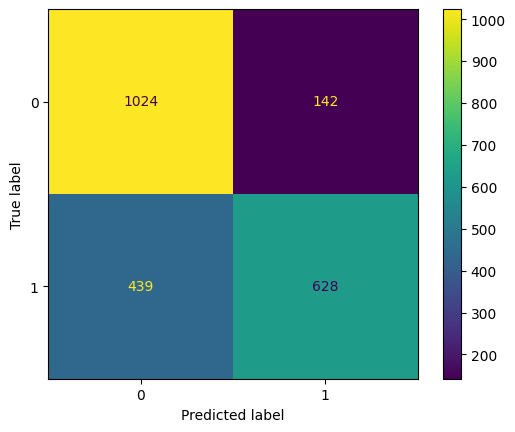

In [26]:
Disp_cm = ConfusionMatrixDisplay(confusion_matrix=con_mat,display_labels=nb_model.classes_)
Disp_cm.plot()
plt.show()

In [27]:
y1 = df['deposit_yes']
X1 = df.drop(columns=['deposit_yes','duration'])

X_train1,X_test1,y_train1,y_test1 = train_test_split(X1,y1,test_size=0.2,random_state=42)

nb_model1 = GaussianNB()

nb_model1.fit(X_train1,y_train1)

y_train_predict1= nb_model1.predict(X_train1)
y_test_predict1 = nb_model1.predict(X_test1)

def evaluate_model(y_true, y_pred, dataset_name):

    print(f"\n{dataset_name} Performance")
    print("-" * 35)

    print(f"Accuracy : {accuracy_score(y_true,y_pred):.4f}")
    print(f"Precision: {precision_score(y_true,y_pred):.4f}")
    print(f"Recall   : {recall_score(y_true,y_pred):.4f}")
    print(f"F1 Score : {f1_score(y_true,y_pred):.4f}")


evaluate_model(y_train1, y_train_predict1, "Train")

evaluate_model(y_test1, y_test_predict1, "Test")


Train Performance
-----------------------------------
Accuracy : 0.6743
Precision: 0.7455
Recall   : 0.4725
F1 Score : 0.5784

Test Performance
-----------------------------------
Accuracy : 0.6883
Precision: 0.7724
Recall   : 0.4930
F1 Score : 0.6018


In [28]:
con_mat1 = confusion_matrix(y_test1,y_test_predict1,labels=nb_model1.classes_)
con_mat1

array([[1011,  155],
       [ 541,  526]], dtype=int64)

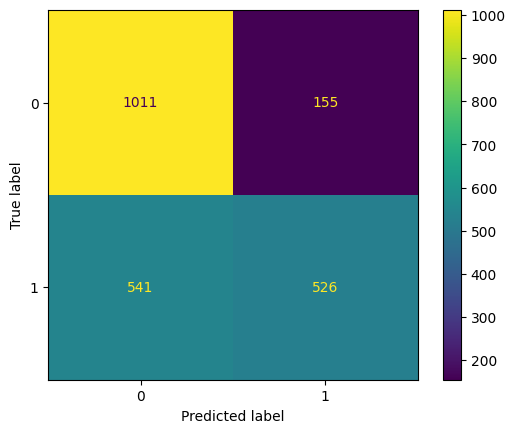

In [29]:
Disp_cm1 = ConfusionMatrixDisplay(confusion_matrix=con_mat1,display_labels=nb_model1.classes_)
Disp_cm1.plot()
plt.show()

In [30]:
print(classification_report(y_test,y_test_predict))

              precision    recall  f1-score   support

           0       0.70      0.88      0.78      1166
           1       0.82      0.59      0.68      1067

    accuracy                           0.74      2233
   macro avg       0.76      0.73      0.73      2233
weighted avg       0.76      0.74      0.73      2233



#### The duration variable significantly improved predictive performance, increasing F1 Score from 60% to 68%. However, since call duration is only known after customer contact, it may introduce target leakage for pre-campaign prediction use cases. Therefore, the duration-excluded model is recommended for operational deployment, while the duration-inclusive model provides valuable insight into factors associated with successful conversions.

### Conclusion

The analysis identified several factors associated with successful term deposit subscriptions. Cellular communication channels produced stronger conversion outcomes than telephone-based outreach. Customers aged 26–45 and those in management, technician, and retired occupations showed higher subscription rates. Previous campaign interactions also positively influenced customer conversion.

The Gaussian Naive Bayes model achieved approximately 68% accuracy on unseen data, demonstrating a reasonable ability to distinguish between customers likely and unlikely to subscribe. The model maintained similar training and testing performance, indicating good generalization with minimal overfitting.